# Large-Scale Geographic Consumer Clustering & High-Dimensional Visualizations

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully.")

All libraries imported successfully.


## Load Dataset

In [14]:
df=pd.read_csv("/content/Large_Scale_Geographic_Consumer_Clustering_Dataset.csv")
print(df.shape)

(100000, 16)


## Dataset Information

In [15]:
df.info()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Property_ID          100000 non-null  int64  
 1   Latitude             100000 non-null  float64
 2   Longitude            100000 non-null  float64
 3   Property_Area_sqft   99000 non-null   float64
 4   Bedrooms             99000 non-null   float64
 5   Bathrooms            100000 non-null  int64  
 6   Age_of_Property      100000 non-null  int64  
 7   Parking_Spaces       100000 non-null  int64  
 8   Nearby_Schools_km    100000 non-null  float64
 9   Nearby_Hospitals_km  100000 non-null  float64
 10  Crime_Index          100000 non-null  float64
 11  Population_Density   100000 non-null  int64  
 12  Average_Income       99000 non-null   float64
 13  Property_Price       100000 non-null  int64  
 14  Property_Type        100000 non-null  object 
 15  City              

## Check Missing Values

In [16]:
print(df.isnull().sum())

Property_ID               0
Latitude                  0
Longitude                 0
Property_Area_sqft     1000
Bedrooms               1000
Bathrooms                 0
Age_of_Property           0
Parking_Spaces            0
Nearby_Schools_km         0
Nearby_Hospitals_km       0
Crime_Index               0
Population_Density        0
Average_Income         1000
Property_Price            0
Property_Type             0
City                      0
dtype: int64


## Select Important Numerical Columns

In [17]:
numeric_columns=df.select_dtypes(include=np.number).columns.tolist()
print(numeric_columns)
latitude=None
longitude=None
for col in numeric_columns:
    name=col.lower()
    if 'lat' in name: latitude=col
    if 'lon' in name or 'lng' in name or 'long' in name: longitude=col
if latitude and longitude:
    print(latitude, longitude)
else:
    print("Latitude/Longitude not found. Using first numerical columns.")

['Property_ID', 'Latitude', 'Longitude', 'Property_Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_of_Property', 'Parking_Spaces', 'Nearby_Schools_km', 'Nearby_Hospitals_km', 'Crime_Index', 'Population_Density', 'Average_Income', 'Property_Price']
Population_Density Longitude


## Data Cleaning

In [18]:
data=df[numeric_columns].copy()
data=data.fillna(data.mean())
print(data.isnull().sum())

Property_ID            0
Latitude               0
Longitude              0
Property_Area_sqft     0
Bedrooms               0
Bathrooms              0
Age_of_Property        0
Parking_Spaces         0
Nearby_Schools_km      0
Nearby_Hospitals_km    0
Crime_Index            0
Population_Density     0
Average_Income         0
Property_Price         0
dtype: int64


## Feature Scaling

In [19]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data)
print(scaled_data.shape)

(100000, 14)


## Elbow Method

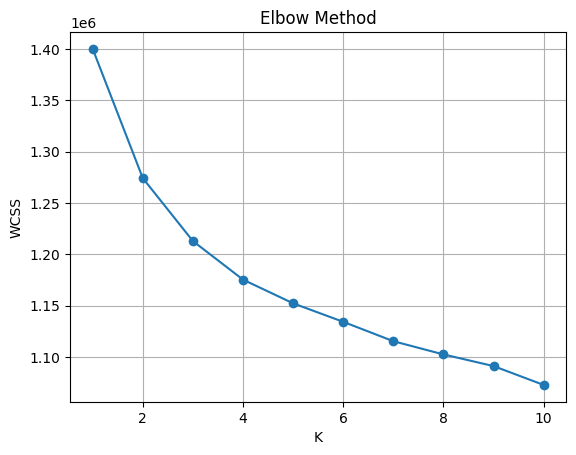

Choose the elbow point.


In [20]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()
print("Choose the elbow point.")

## Train K-Means

In [21]:
k=3
kmeans=KMeans(n_clusters=k,random_state=42)
clusters=kmeans.fit_predict(scaled_data)
print("Model trained.")

Model trained.


## Add Cluster Labels

In [22]:
df["Cluster"]=clusters
df.head()

,Property_ID,Latitude,Longitude,Property_Area_sqft,Bedrooms,Bathrooms,Age_of_Property,Parking_Spaces,Nearby_Schools_km,Nearby_Hospitals_km,Crime_Index,Population_Density,Average_Income,Property_Price,Property_Type,City,Cluster
0,1,18.946475,72.770085,4838.0,1.0,1,29,1,1.80,5.84,75.50,15355,1472211.0,24815630,Independent House,Mumbai,0
1,2,28.608112,77.301325,1621.0,1.0,1,39,3,5.15,2.07,77.12,25555,2304400.0,33907545,Commercial,Delhi,1
2,3,13.081556,80.307162,4936.0,4.0,1,9,1,12.11,6.18,74.11,14619,433318.0,32815212,Apartment,Chennai,2
3,4,19.033312,72.901517,4765.0,4.0,4,8,1,2.84,5.21,7.59,8679,1028202.0,47324848,Independent House,Mumbai,0
4,5,19.065029,72.843596,704.0,4.0,4,17,3,8.70,8.78,40.15,15859,431433.0,49037399,Independent House,Mumbai,0


## Cluster Visualization

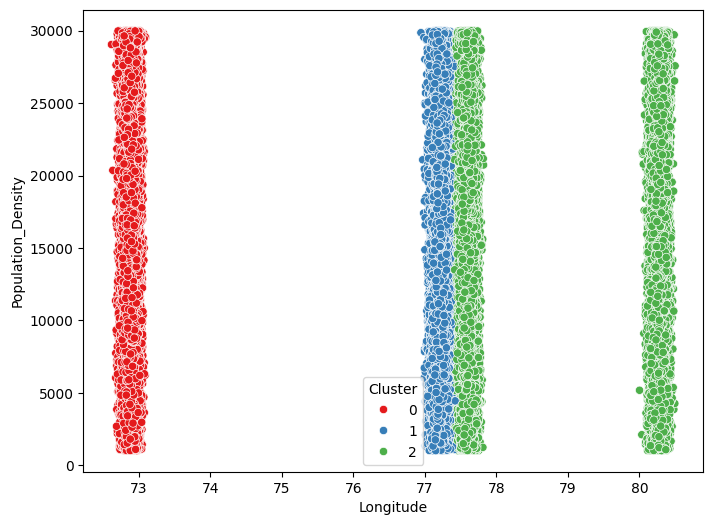

In [23]:
plt.figure(figsize=(8,6))
if latitude and longitude:
    sns.scatterplot(data=df,x=longitude,y=latitude,hue="Cluster",palette="Set1")
else:
    sns.scatterplot(data=df,x=numeric_columns[0],y=numeric_columns[1],hue="Cluster",palette="Set1")
plt.show()

## Cluster Summary

In [24]:
summary=df.groupby("Cluster")[numeric_columns].mean()
summary

,Property_ID,Latitude,Longitude,Property_Area_sqft,Bedrooms,Bathrooms,Age_of_Property,Parking_Spaces,Nearby_Schools_km,Nearby_Hospitals_km,Crime_Index,Population_Density,Average_Income,Property_Price
Cluster,,,,,,,,,,,,,,
0,50017.465566,19.075838,72.877640,2720.414512,3.506490,3.002692,19.396737,1.502451,7.608331,6.103499,49.834735,15463.899229,1.351345e+06,2.568714e+07
1,49903.752443,28.613617,77.209381,2725.655050,3.498320,3.004445,19.475092,1.499640,7.634553,6.106056,49.938209,15420.332492,1.350697e+06,2.578246e+07
2,50040.263482,13.027558,78.931540,2726.039473,3.498157,2.999442,19.450598,1.498763,7.608832,6.083445,50.086580,15467.305126,1.346193e+06,2.569974e+07


## Predict Cluster for New Sample

In [25]:
sample=data.mean().values.reshape(1,-1)
sample_scaled=scaler.transform(sample)
prediction=kmeans.predict(sample_scaled)
print("Predicted Cluster:",prediction[0])

Predicted Cluster: 2


## Conclusion

In [26]:
print("Project Completed Successfully")
print("Dataset loaded, cleaned, scaled, clustered, visualized and summarized using K-Means.")

Project Completed Successfully
Dataset loaded, cleaned, scaled, clustered, visualized and summarized using K-Means.
